# Figure 3E — how guide modules distribute across transcription clusters

Two views of the same composition: what fraction of each module's cells falls
in each cluster (Supp. 4D), and what fraction of each cluster's cells comes
from each module (Supp. 4E). Figure 3E itself is the enrichment heatmap —
which modules are over- or under-represented in which clusters.

## Setup

In [1]:
library(ggplot2)
library(reshape2)
library(pheatmap)

# NOTE: Main.R is deliberately not sourced. It loads ICtest, whose Ops method
# conflicts with the S7 objects in ggplot2 4.x and makes every `+` chain fail
# with 'Incompatible methods ("Ops.S7_object", "+.gg")'.

save_pheatmap_pdf <- function(x, filename, width = 7, height = 7) {
    stopifnot(!missing(x), !missing(filename))
    pdf(filename, width = width, height = height)
    grid::grid.newpage()
    grid::grid.draw(x$gtable)
    dev.off()
}

FIGURE_DIR <- "figures"
dir.create(FIGURE_DIR, showWarnings = FALSE)

In [2]:
RDS_DIR <- "/home/eraslab1/Projects/E3Ligase/analysisSingle/outputs/RDSFiles"
COMPOSITION_RDS <- file.path(RDS_DIR, "KOGroupsPerLeiden.rds")
ENRICHMENT_RDS  <- file.path(RDS_DIR, "KOGroupsPerLeiden_withTests.rds")

# guide modules are named by NewGuideGroup; the stored objects still use the
# older G_<n> keys
MODULE_NAME <- c("G_0" = "M2", "G_1" = "M3", "G_2" = "M6",
                 "G_3" = "M5", "G_4" = "M1", "G_5" = "M4",
                 "G_CONTROL" = "CONTROL")

MODULE_COLORS <- c("M1" = "#aa40fc", "M2" = "#1f77b4", "M3" = "#ff7f0e",
                   "M4" = "#8c564b", "M5" = "#d62728", "M6" = "#279e68",
                   "CONTROL" = "#bbbbbb")

# transcription clusters, renamed and numbered from 1. Cluster number and
# identity are a fixed pairing; the renumbering changes which transcription
# cluster carries which number.
CLUSTER_NAME <- c("0" = "Cluster 1: DC2.1",
                  "1" = "Cluster 2: DC2.2",
                  "2" = "Cluster 3: DC2.3",
                  "3" = "Cluster 8: DC1",
                  "4" = "Cluster 4: DC2.4",
                  "5" = "Cluster 5: DC2.5",
                  "6" = "Cluster 7: Migratory DCs",
                  "7" = "Cluster 6: DC2.6",
                  "8" = "Cluster 9: Cycling monocyte-derived macrophages",
                  "9" = "Cluster 10: neutrophil")

CLUSTER_COLORS <- setNames(
    c("#1f77b4", "#ff7f0e", "#279e68", "#d62728", "#aa40fc",
      "#8c564b", "#e377c2", "#b5bd61", "#17becf", "#aec7e8"),
    CLUSTER_NAME[as.character(0:9)]
)

# which transcription cluster each renumbered cluster refers to
TC_OF_CLUSTER <- c("1" = "0", "2" = "1", "3" = "2", "4" = "4", "5" = "5",
                   "6" = "7", "7" = "6", "8" = "3", "9" = "8", "10" = "9")

# layout of the Figure 3E heatmap
ROW_ORDER     <- c(9, 8, 1, 4, 3, 6, 7, 5, 2, 10)
CLUSTER_ORDER <- CLUSTER_NAME[TC_OF_CLUSTER[as.character(ROW_ORDER)]]
MODULE_ORDER  <- c("M5", "M3", "CONTROL", "M1", "M4", "M2", "M6")

# axis orders for the bar charts: modules and clusters in their own order
MODULE_BAR_ORDER  <- c("M1", "M2", "M3", "M4", "M5", "M6", "CONTROL")
CLUSTER_BAR_ORDER <- CLUSTER_NAME[TC_OF_CLUSTER[as.character(1:10)]]

FDR_THRESHOLD    <- 0.1
ODDS_RATIO_RANGE <- c(0.6, 1.4)   # clamp so a few extremes do not flatten the scale

## Composition — Supp. 4D and 4E

:::{note}
Dirichlet regression would be the natural test for compositional differences,
but the screen provides only one sample per composition, so there is nothing
to regress against. The enrichment below uses per-cluster Fisher tests instead.
:::

In [3]:
composition <- readRDS(COMPOSITION_RDS)
clusterCounts <- as.data.frame(composition[, 1:10])
colnames(clusterCounts) <- CLUSTER_NAME[colnames(clusterCounts)]   # label, not index
moduleOf <- MODULE_NAME[as.character(composition$KOGuide)]

# one bar per module: where that module's cells sit
perModule <- clusterCounts / rowSums(clusterCounts)
perModule$group <- moduleOf

# one bar per cluster: which modules its cells came from
perCluster <- as.data.frame(t(clusterCounts))
colnames(perCluster) <- moduleOf
perCluster <- perCluster / rowSums(perCluster)
perCluster$group <- rownames(perCluster)

dim(perModule); dim(perCluster)

[1]  7 11

[1] 10  8

In [4]:
# both panels are the same stacked bar chart with the roles swapped
stackedBar <- function(df, barOrder, fillOrder, xLabel, fillLabel, colours, filename) {
    melted <- melt(df, id.vars = "group")
    melted$group    <- factor(melted$group, levels = barOrder)
    melted$variable <- factor(melted$variable, levels = fillOrder)
    p <- ggplot(melted, aes(x = group, y = value, fill = variable)) +
        theme_minimal() +
        geom_bar(stat = "identity") +
        scale_fill_manual(name = fillLabel, values = colours) +
        ylab("Percent of cells") + xlab(xLabel) +
        theme(axis.text = element_text(size = 11),
              axis.text.x = element_text(angle = 45, hjust = 1),
              axis.title = element_text(size = 14),
              legend.text = element_text(size = 10),
              legend.title = element_text(size = 12),
              legend.position = "right")     # was legend.pos, which theme() ignores
    ggsave(file.path(FIGURE_DIR, filename), p, width = 10, height = 6)
    p
}

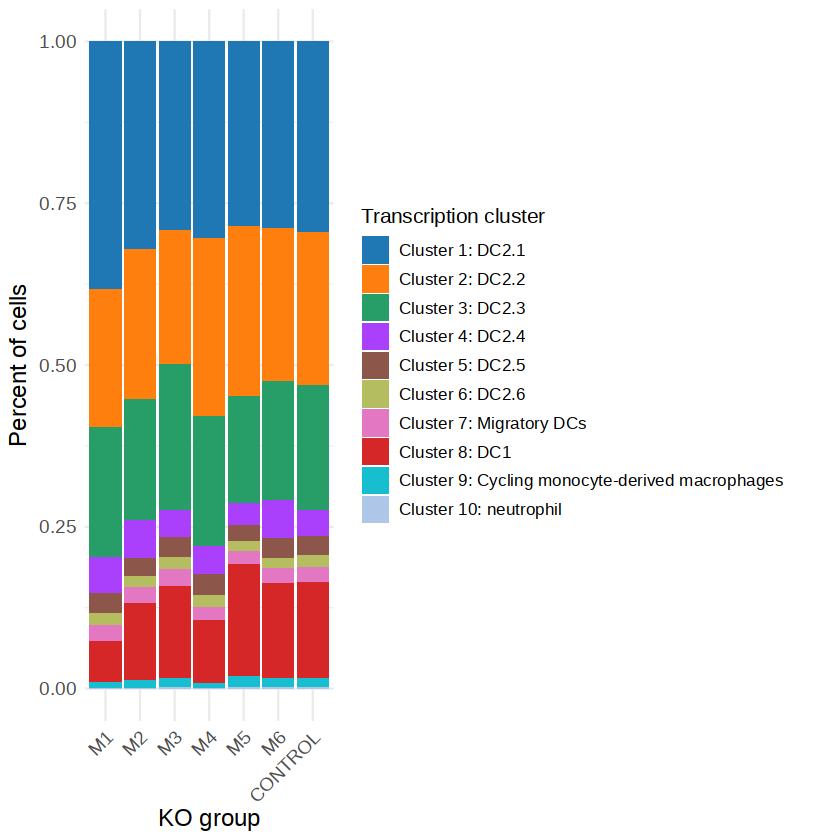

In [5]:
stackedBar(perModule, MODULE_BAR_ORDER, CLUSTER_BAR_ORDER,
           "KO group", "Transcription cluster", CLUSTER_COLORS, "S_4D.pdf")

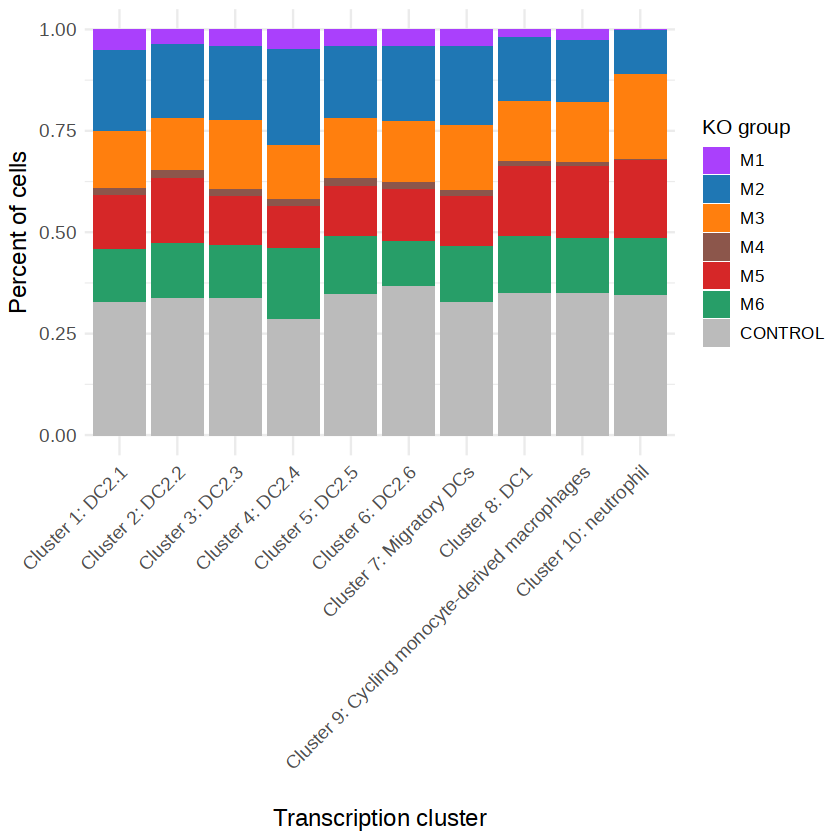

In [6]:
stackedBar(perCluster, CLUSTER_BAR_ORDER, MODULE_BAR_ORDER,
           "Transcription cluster", "KO group", MODULE_COLORS, "S_4E.pdf")

## Enrichment of each module in each cluster — Figure 3E

The stored object already carries the per-cluster Fisher tests and their FDRs;
significant tests contribute their odds ratio, everything else stays at 1.

In [7]:
enrichment <- readRDS(ENRICHMENT_RDS)

fdrColumns <- c(paste0("Leiden", 0:9, "_FDR_greater"), paste0("Leiden", 0:9, "_FDR_less"))
significant <- melt(enrichment[, c(fdrColumns, "KOGuide")], id.vars = "KOGuide")
significant <- significant[significant$value < FDR_THRESHOLD, ]

significant$cluster  <- sapply(significant$variable, function(x) strsplit(as.character(x), "_")[[1]][1])
significant$testType <- sapply(significant$variable, function(x) strsplit(as.character(x), "_")[[1]][3])
significant$oddRatio <- mapply(
    function(guide, cluster, direction) enrichment[guide, paste0(cluster, "_estimate_", direction)],
    significant$KOGuide, significant$cluster, significant$testType
)

kk <- data.frame(matrix(1.0, nrow = 10, ncol = length(unique(significant$KOGuide))))
colnames(kk) <- unique(significant$KOGuide)
rownames(kk) <- paste0("Leiden", 0:9)
for (i in seq_len(nrow(significant))) {
    kk[significant[i, "cluster"], significant[i, "KOGuide"]] <- significant[i, "oddRatio"]
}

rownames(kk) <- CLUSTER_NAME[sub("Leiden", "", rownames(kk))]
colnames(kk) <- MODULE_NAME[colnames(kk)]
kk[kk < ODDS_RATIO_RANGE[1]] <- ODDS_RATIO_RANGE[1]
kk[kk > ODDS_RATIO_RANGE[2]] <- ODDS_RATIO_RANGE[2]
dim(kk)

[1] 10  7

agg_record_366863827 
                   2

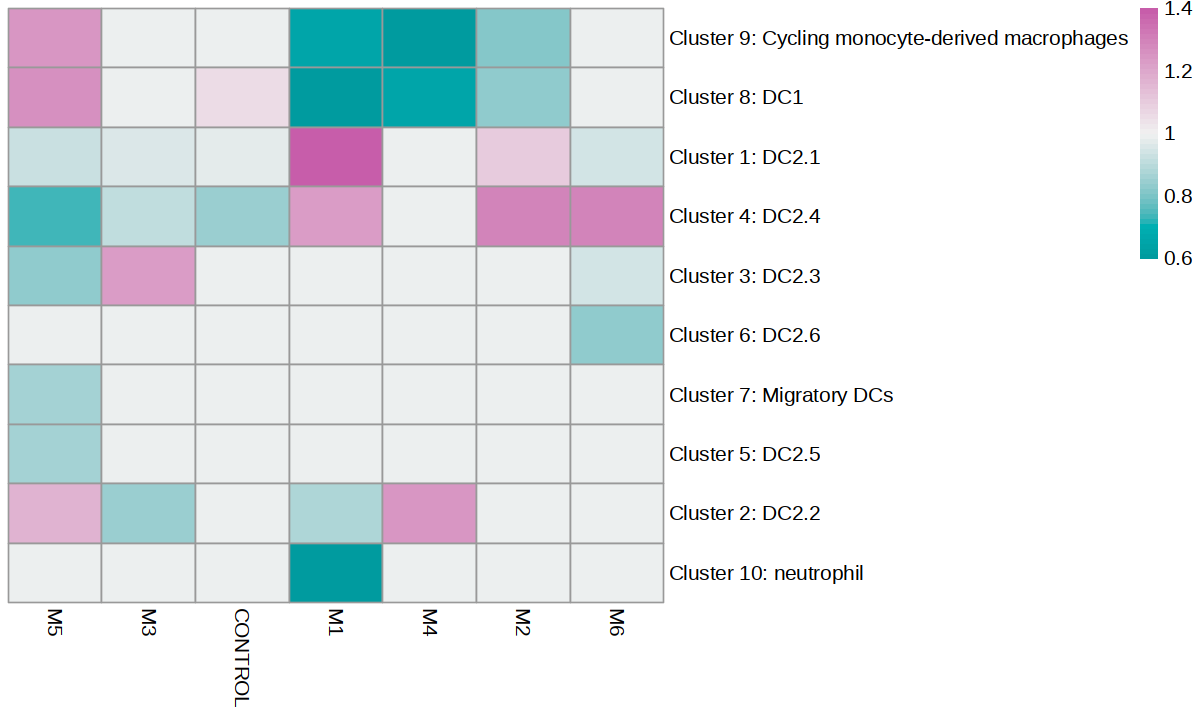

In [8]:
options(repr.plot.width = 10, repr.plot.height = 6)

heatmap3E <- pheatmap(kk[CLUSTER_ORDER, MODULE_ORDER],
                      cluster_rows = FALSE, cluster_cols = FALSE,
                      treeheight_col = 0, treeheight_row = 0,
                      color = hcl.colors(50, "Tropic"), fontsize = 12)

save_pheatmap_pdf(heatmap3E, file.path(FIGURE_DIR, "Figure3_E.pdf"), width = 8, height = 6)